# Low-FPS Multi-Object Tracker — Jupyter Visualizer
Tracks people and vehicles in video files or webcam streams, with inline frame display.

**Requirements:** `pip install ultralytics sahi filterpy scipy opencv-python torch torchvision ipywidgets tqdm matplotlib`

# Para correr "headless" e gerar video de saida usar script run_tracker.py:

**Command :** `python run_tracker_silent.py --source "../teste.mp4" --conf 0.15 --output "pvcentral.mp4"  --model "../../yolo11x.pt" --silent --max-age X --csv output.csv`

X - numero de frames em que mantem trajectorias "alive" (por causa da oclusão).
### YOLO tracking website
https://docs.ultralytics.com/modes/track/

In [1]:
# ── Imports ───────────────────────────────────────────────────────────────────
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch
import matplotlib.colors as mcolors
from IPython.display import display, clear_output
import ipywidgets as widgets
from tqdm.notebook import tqdm
import time
import pandas as pd
from collections import defaultdict
import sys
import os

# Make sure tracker.py is on the path
sys.path.insert(0, os.path.dirname(os.path.abspath('tracker.py')))
from tracker import LowFPSTracker, TrackerConfig

print('All imports OK')

All imports OK


In [19]:
# ── Config ────────────────────────────────────────────────────────────────────
# Edit these before running

SOURCE      = '../teste.mp4'   # path to video file, or integer (0) for webcam
FPS_SIM     = 1                # process every N-th frame (simulates low FPS)
MAX_FRAMES  = None           # max frames to process (None = full video)
CONF        = 0.15
USE_SAHI    = False
YOLO_MODEL  = '../../yolo11x.pt'

# Display
DISPLAY_EVERY = 30           # show every N-th processed frame inline (1 = all)
FIG_WIDTH     = 14          # figure width in inches
TRAIL_LEN     = 20          # number of past center positions to draw as trail

In [3]:
# ── Colour palette ────────────────────────────────────────────────────────────
CLASS_NAMES = {0: 'person', 2: 'car', 3: 'moto', 5: 'bus', 7: 'truck'}

# Matplotlib-compatible RGB [0,1]
CLASS_COLORS_MPL = {
    0: (0.39, 0.86, 0.39),   # person  — green
    2: (0.31, 0.63, 1.00),   # car     — blue
    3: (1.00, 0.71, 0.24),   # moto    — amber
    5: (0.78, 0.31, 1.00),   # bus     — purple
    7: (0.24, 0.86, 0.86),   # truck   — cyan
}

# OpenCV-compatible BGR uint8 (for drawing on numpy frames)
CLASS_COLORS_CV = {
    0: (100, 220, 100),
    2: ( 80, 160, 255),
    3: (255, 180,  60),
    5: (200,  80, 255),
    7: ( 60, 220, 220),
}

def track_color_mpl(track_id: int, class_id: int):
    """Per-track hue variation so IDs are visually distinct."""
    base = CLASS_COLORS_MPL.get(class_id, (0.7, 0.7, 0.7))
    h, s, v = mcolors.rgb_to_hsv(base)
    h = (h + (track_id * 0.13)) % 1.0   # rotate hue by track ID
    return mcolors.hsv_to_rgb((h, s * 0.85, v))

print('Palette ready')

Palette ready


In [4]:
# ── Trail store ───────────────────────────────────────────────────────────────
# Keeps a rolling history of center positions per track for motion trails
trail_store: dict = defaultdict(list)   # track_id -> [(cx, cy), ...]

def update_trails(tracks: list):
    for t in tracks:
        x1, y1, x2, y2 = t['bbox']
        cx, cy = (x1 + x2) / 2, (y1 + y2) / 2
        trail_store[t['id']].append((cx, cy))
        if len(trail_store[t['id']]) > TRAIL_LEN:
            trail_store[t['id']].pop(0)

print('Trail store ready')

Trail store ready


In [5]:
# ── Matplotlib frame renderer ─────────────────────────────────────────────────

def render_frame_mpl(frame_bgr: np.ndarray, tracks: list,
                     frame_id: int, dt_ms: float,
                     ax: plt.Axes):
    """Draw detections, labels and motion trails onto a matplotlib Axes."""
    frame_rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)
    ax.clear()
    ax.imshow(frame_rgb, aspect='auto')
    ax.set_axis_off()

    h, w = frame_bgr.shape[:2]

    for t in tracks:
        x1, y1, x2, y2 = t['bbox']
        tid   = t['id']
        cls   = t['class_id']
        state = t['state']
        color = track_color_mpl(tid, cls)
        label = f"{CLASS_NAMES.get(cls, 'obj')} #{tid}"
        lw    = 1.8 if state == 'confirmed' else 0.9
        alpha = 1.0 if state == 'confirmed' else 0.55

        # Bounding box
        rect = FancyBboxPatch(
            (x1, y1), x2 - x1, y2 - y1,
            boxstyle='square,pad=0',
            linewidth=lw, edgecolor=color,
            facecolor='none', alpha=alpha
        )
        ax.add_patch(rect)

        # Label chip (top-left of box)
        ax.text(
            x1 + 2, y1 - 3, label,
            fontsize=7, color='white', fontweight='bold',
            va='bottom', ha='left',
            bbox=dict(boxstyle='round,pad=0.2', fc=color, ec='none', alpha=0.85)
        )

        # Center dot
        cx, cy = (x1 + x2) / 2, (y1 + y2) / 2
        ax.plot(cx, cy, 'o', color=color, markersize=3, alpha=alpha)

        # Motion trail (fading opacity)
        trail = trail_store.get(tid, [])
        if len(trail) >= 2:
            txs = [p[0] for p in trail]
            tys = [p[1] for p in trail]
            n   = len(trail)
            for i in range(1, n):
                seg_alpha = (i / n) * 0.75 * alpha
                ax.plot(txs[i-1:i+1], tys[i-1:i+1],
                        '-', color=color, linewidth=1.2, alpha=seg_alpha)

    # HUD overlay
    confirmed = sum(1 for t in tracks if t['state'] == 'confirmed')
    hud = (f"Frame {frame_id}   Tracks: {len(tracks)} "
           f"({confirmed} confirmed)   {dt_ms:.0f} ms/frame")
    ax.set_title(hud, fontsize=9, loc='left', pad=4,
                 color='white',
                 bbox=dict(fc='#111111cc', ec='none', pad=3))

    # Legend
    legend_handles = [
        mpatches.Patch(color=CLASS_COLORS_MPL.get(cid, (0.7,0.7,0.7)), label=name)
        for cid, name in CLASS_NAMES.items()
    ]
    ax.legend(handles=legend_handles, fontsize=7,
              loc='upper right', framealpha=0.7,
              facecolor='#111111', labelcolor='white',
              edgecolor='none')

print('Renderer ready')

Renderer ready


[Tracker] device=cuda  model=../../yolo11x.pt  sahi=off
Source: ../teste.mp4  1280x800 @ 30.0 fps  total frames: 7792


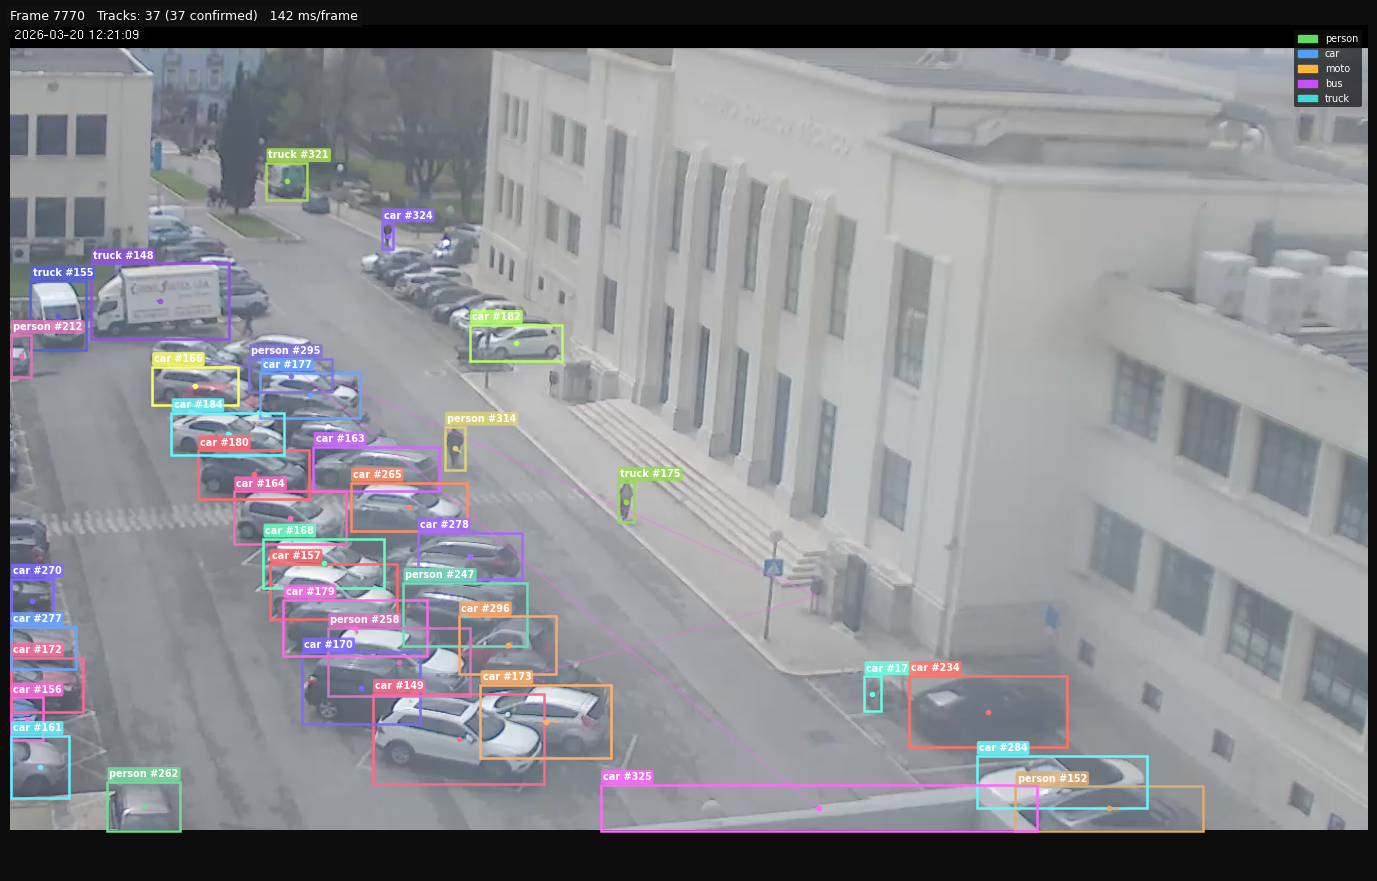

Tracking:   0%|          | 0/7792 [00:00<?, ?frame/s]

Done. 7792 frames in 1491.7s (5.2 fps throughput)
Total detections accumulated: 351121


In [20]:
# ── Run tracker ───────────────────────────────────────────────────────────────

cfg = TrackerConfig(
    yolo_model=YOLO_MODEL,
    det_conf_thresh=CONF,
    use_sahi=USE_SAHI,
)
tracker = LowFPSTracker(cfg)
trail_store.clear()

source = int(SOURCE) if str(SOURCE).isdigit() else SOURCE
cap    = cv2.VideoCapture(source)
if not cap.isOpened():
    raise RuntimeError(f'Cannot open: {SOURCE}')

total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
orig_fps = cap.get(cv2.CAP_PROP_FPS) or 30
W = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
H = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
print(f'Source: {SOURCE}  {W}x{H} @ {orig_fps:.1f} fps  total frames: {total or "live"}')

# Results accumulator for CSV export later
all_rows = []

fig_h = FIG_WIDTH * H / W
fig, ax = plt.subplots(1, 1, figsize=(FIG_WIDTH, fig_h))
fig.patch.set_facecolor('#0d0d0d')
plt.tight_layout(pad=0)
out = display(fig, display_id=True)

fidx       = 0
proc_count = 0
t_start    = time.perf_counter()

pbar_total = (MAX_FRAMES or total or 0)
pbar = tqdm(total=pbar_total or None, unit='frame', desc='Tracking')

try:
    while True:
        ret, frame = cap.read()
        if not ret:
            break
        fidx += 1

        if fidx % FPS_SIM != 0:
            continue

        t0      = time.perf_counter()
        tracks  = tracker.update(frame)
        dt_ms   = (time.perf_counter() - t0) * 1000
        ts      = time.perf_counter() - t_start
        proc_count += 1

        # Accumulate results
        for t in tracks:
            x1, y1, x2, y2 = t['bbox']
            all_rows.append({
                'frame_id':    fidx,
                'timestamp_s': round(ts, 4),
                'track_id':    t['id'],
                'class_id':    t['class_id'],
                'class_name':  CLASS_NAMES.get(t['class_id'], 'unknown'),
                'state':       t['state'],
                'x1': round(x1,2), 'y1': round(y1,2),
                'x2': round(x2,2), 'y2': round(y2,2),
                'width':  round(x2-x1,2),
                'height': round(y2-y1,2),
                'cx': round((x1+x2)/2,2),
                'cy': round((y1+y2)/2,2),
            })

        update_trails(tracks)

        # Render inline every DISPLAY_EVERY processed frames
        if proc_count % DISPLAY_EVERY == 0:
            render_frame_mpl(frame, tracks, fidx, dt_ms, ax)
            out.update(fig)

        pbar.update(1)
        if MAX_FRAMES and proc_count >= MAX_FRAMES:
            break

finally:
    cap.release()
    pbar.close()
    plt.close(fig)

elapsed = time.perf_counter() - t_start
print(f'Done. {proc_count} frames in {elapsed:.1f}s '
      f'({proc_count/max(elapsed,0.001):.1f} fps throughput)')
print(f'Total detections accumulated: {len(all_rows)}')

In [21]:
# ── Results DataFrame ─────────────────────────────────────────────────────────
df = pd.DataFrame(all_rows)
print(f'Shape: {df.shape}')
df.head(10)

Shape: (351121, 14)


,frame_id,timestamp_s,track_id,class_id,class_name,state,x1,y1,x2,y2,width,height,cx,cy
0,1,0.3873,148,7,truck,tentative,76.05,236.15,199.84,310.99,123.80,74.84,137.95,273.57
1,1,0.3873,149,2,car,tentative,341.88,665.70,504.22,752.75,162.35,87.05,423.05,709.22
2,1,0.3873,150,0,person,tentative,581.56,392.46,597.06,434.50,15.50,42.05,589.31,413.48
3,1,0.3873,151,0,person,tentative,512.19,375.71,528.61,417.68,16.42,41.97,520.40,396.69
4,1,0.3873,152,0,person,tentative,542.27,392.45,558.55,431.82,16.28,39.38,550.41,412.13
5,1,0.3873,153,0,person,tentative,59.33,369.99,72.66,409.68,13.33,39.70,66.00,389.83
6,1,0.3873,154,0,person,tentative,71.38,371.67,85.39,412.58,14.00,40.91,78.38,392.12
7,1,0.3873,155,7,truck,tentative,17.69,253.01,71.76,322.59,54.07,69.58,44.73,287.80
8,1,0.3873,156,2,car,tentative,0.10,666.74,32.01,711.46,31.91,44.72,16.05,689.10
9,1,0.3873,157,2,car,tentative,242.32,536.59,366.66,592.27,124.34,55.68,304.49,564.43


In [22]:
# ── Export to CSV ─────────────────────────────────────────────────────────────
CSV_OUT = 'tracks.csv'
df.to_csv(CSV_OUT, index=False)
print(f'Saved {len(df)} rows → {CSV_OUT}')

Saved 351121 rows → tracks.csv


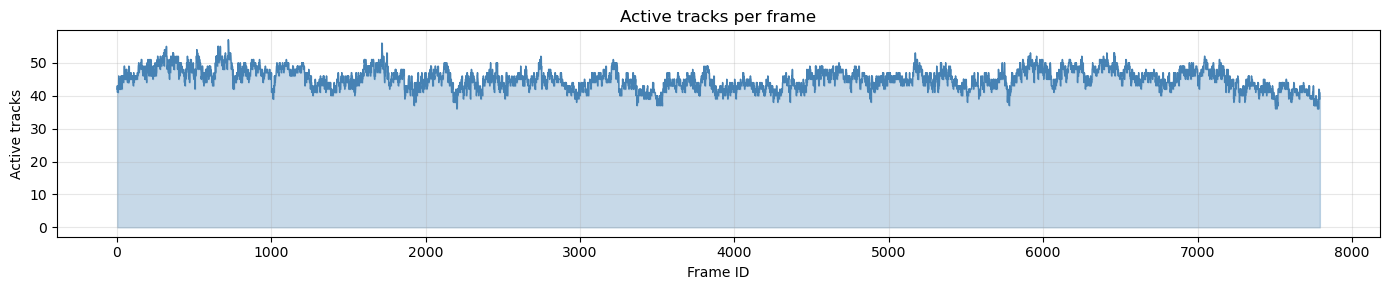

In [23]:
# ── Analytics: tracks per frame ───────────────────────────────────────────────
if df.empty:
    print('No data to plot.')
else:
    per_frame = df.groupby('frame_id')['track_id'].nunique()

    fig, ax = plt.subplots(figsize=(FIG_WIDTH, 3))
    ax.fill_between(per_frame.index, per_frame.values, alpha=0.3, color='steelblue')
    ax.plot(per_frame.index, per_frame.values, color='steelblue', linewidth=1)
    ax.set_xlabel('Frame ID')
    ax.set_ylabel('Active tracks')
    ax.set_title('Active tracks per frame')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

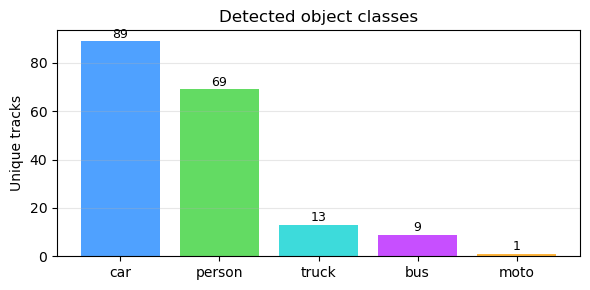

In [24]:
# ── Analytics: class distribution ────────────────────────────────────────────
if df.empty:
    print('No data to plot.')
else:
    counts = df.drop_duplicates(['track_id','class_name'])['class_name'].value_counts()
    colors = [CLASS_COLORS_MPL.get(k, (0.7,0.7,0.7))
              for k in [c for c, n in CLASS_NAMES.items() if n in counts.index]]

    fig, ax = plt.subplots(figsize=(6, 3))
    bars = ax.bar(counts.index, counts.values,
                  color=[CLASS_COLORS_MPL.get(
                      next((k for k,v in CLASS_NAMES.items() if v==name), 0),
                      (0.7,0.7,0.7)) for name in counts.index])
    ax.set_ylabel('Unique tracks')
    ax.set_title('Detected object classes')
    for bar, val in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                str(val), ha='center', va='bottom', fontsize=9)
    ax.grid(True, axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

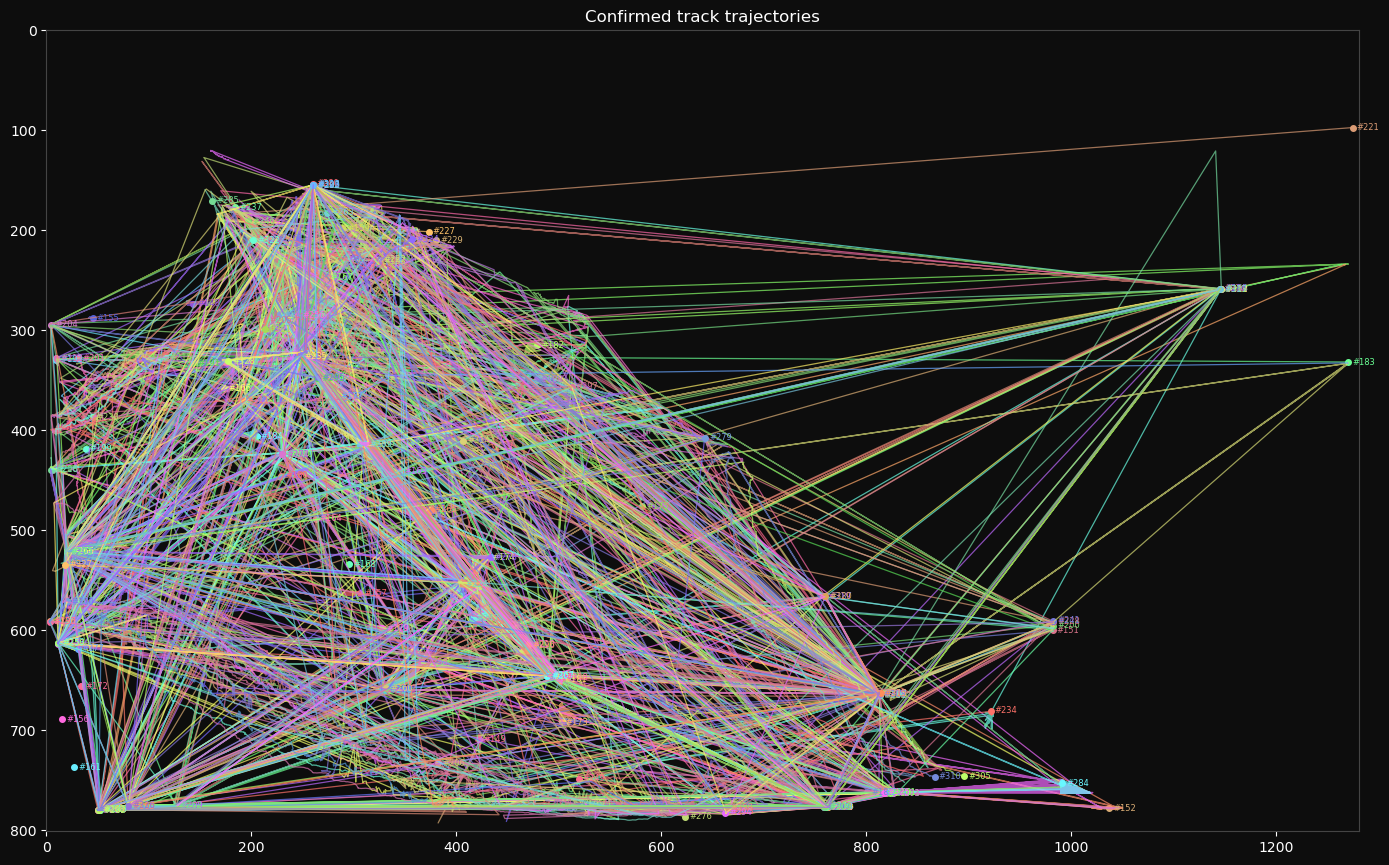

In [25]:
# ── Analytics: trajectory map ─────────────────────────────────────────────────
# Plots center-point trajectories of all confirmed tracks on a blank canvas
if df.empty:
    print('No data to plot.')
else:
    confirmed_df = df[df['state'] == 'confirmed']
    W_src = df['x2'].max()
    H_src = df['y2'].max()

    fig, ax = plt.subplots(figsize=(FIG_WIDTH, FIG_WIDTH * H_src / max(W_src, 1)))
    ax.set_xlim(0, W_src)
    ax.set_ylim(H_src, 0)   # y-axis flipped to match image coords
    ax.set_facecolor('#0d0d0d')
    fig.patch.set_facecolor('#0d0d0d')
    ax.set_title('Confirmed track trajectories', color='white')
    ax.tick_params(colors='white')
    for spine in ax.spines.values():
        spine.set_edgecolor('#444')

    for tid, grp in confirmed_df.groupby('track_id'):
        grp = grp.sort_values('frame_id')
        cls  = grp['class_id'].iloc[0]
        col  = track_color_mpl(tid, cls)
        ax.plot(grp['cx'], grp['cy'], '-', color=col, linewidth=0.9, alpha=0.7)
        ax.plot(grp['cx'].iloc[-1], grp['cy'].iloc[-1],
                'o', color=col, markersize=4)
        ax.text(grp['cx'].iloc[-1] + 4, grp['cy'].iloc[-1],
                f'#{tid}', fontsize=6, color=col, va='center')

    plt.tight_layout()
    plt.show()

In [26]:
# ── Interactive single-track inspector ───────────────────────────────────────
# Select any track ID to see its bounding box size over time
if df.empty:
    print('No data.')
else:
    track_ids = sorted(df['track_id'].unique().tolist())
    dropdown  = widgets.Dropdown(options=track_ids, description='Track ID:')
    out_w     = widgets.Output()

    def on_change(change):
        with out_w:
            clear_output(wait=True)
            tid  = change['new']
            grp  = df[df['track_id'] == tid].sort_values('frame_id')
            cls  = grp['class_id'].iloc[0]
            col  = track_color_mpl(tid, cls)

            fig, axes = plt.subplots(1, 3, figsize=(FIG_WIDTH, 3))

            # Box size over time
            axes[0].plot(grp['frame_id'], grp['width'],  label='width',  color=col)
            axes[0].plot(grp['frame_id'], grp['height'], label='height',
                         color=col, linestyle='--')
            axes[0].set_title(f'Track #{tid} — box size')
            axes[0].set_xlabel('Frame'); axes[0].legend(); axes[0].grid(alpha=0.3)

            # Center X/Y over time
            axes[1].plot(grp['frame_id'], grp['cx'], label='cx', color='tomato')
            axes[1].plot(grp['frame_id'], grp['cy'], label='cy', color='steelblue')
            axes[1].set_title(f'Track #{tid} — position')
            axes[1].set_xlabel('Frame'); axes[1].legend(); axes[1].grid(alpha=0.3)

            # Trajectory scatter
            sc = axes[2].scatter(grp['cx'], grp['cy'],
                                 c=grp['frame_id'], cmap='plasma',
                                 s=15, zorder=3)
            axes[2].plot(grp['cx'], grp['cy'], '-', color=col, alpha=0.4, linewidth=1)
            axes[2].invert_yaxis()
            axes[2].set_title(f'Track #{tid} — trajectory (colour = time)')
            axes[2].set_xlabel('cx'); axes[2].set_ylabel('cy')
            plt.colorbar(sc, ax=axes[2], label='frame')
            axes[2].grid(alpha=0.3)

            plt.suptitle(
                f'Track #{tid}  |  class: {CLASS_NAMES.get(cls, "?")}'  
                f'  |  frames: {grp["frame_id"].min()}–{grp["frame_id"].max()}'  
                f'  |  hits: {len(grp)}',
                fontsize=10
            )
            plt.tight_layout()
            plt.show()

    dropdown.observe(on_change, names='value')
    on_change({'new': track_ids[0]})   # render first track immediately
    display(widgets.VBox([dropdown, out_w]))

In [27]:
import torch
torch.device("cpu")

device(type='cpu')